In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
forecast_df = pd.read_csv("Future_sales_forecast.csv")
store_df = pd.read_csv("Cleaned_SalesStoreForecasting.csv")

In [5]:
print(forecast_df.shape)
print(store_df.shape)

(30, 4)
(2121, 10)


In [6]:
forecast_df.head()

,ds,yhat,yhat_lower,yhat_upper
0,2017-12-31,921.544915,0.0,2113.312462
1,2018-01-01,1085.977449,0.0,2359.630024
2,2018-01-02,679.404827,0.0,1912.232706
3,2018-01-03,622.123215,0.0,1976.242120
4,2018-01-04,812.856717,0.0,2104.038840


In [8]:
store_df.head()

,Order Date,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,2,0,2,0,0,261.9600,2,0.00,41.9136
1,2016-11-08,2,0,2,0,1,731.9400,3,0.00,219.5820
2,2015-10-11,3,0,2,0,3,957.5775,5,0.45,-383.0310
3,2014-06-09,3,0,3,0,2,48.8600,7,0.00,14.1694
4,2014-06-09,3,0,3,0,3,1706.1840,9,0.20,85.3092


In [16]:
#daily average demand 
daily_avg_demand = store_df['Sales'].sum()/len(store_df['Order Date'].unique()) #average sale in 1 day
#from Forecaste 
forecasted_demand = forecast_df['yhat'].sum()  #future 30days total predicted sales 
daily_forecaste = forecast_df['yhat'].mean()  #daily sales average of future 30 days , it is less then daily_avg_demand

print(daily_avg_demand)
print(forecasted_demand)

print(daily_forecaste)

834.645439032621
17231.220682979667
574.3740227659889


**INVENTORY CALCULATION**

In [17]:
lead_time = 7
#Reorder point 
reorder_point = daily_forecaste*lead_time 
#Safety stock 
safety_stock = daily_forecaste*1.5
#reorder quantity 
reorder_qty = forecasted_demand + safety_stock
print(reorder_point)
print(safety_stock)
print(reorder_qty)

4020.618159361922
861.5610341489834
18092.78171712865


In [19]:
# ============================================
# INVENTORY OPTIMIZATION FLOW
# ============================================
#
# Warehouse check kiya
#        |
#        v
# Stock = Rs.4,020 (Reorder Point!)
# "Stock itna kam hua - ORDER LAGAO!"
#        |
#        v
# Order karo = Rs.18,092 (Reorder Quantity!)
# "30 din ka demand + Safety buffer"
#        |
#        v
# Extra rakho = Rs.861 (Safety Stock!)
# "Emergency ke liye backup!"
#        |
#        v
# Kabhi Out of Stock Nahi! 
# ============================================

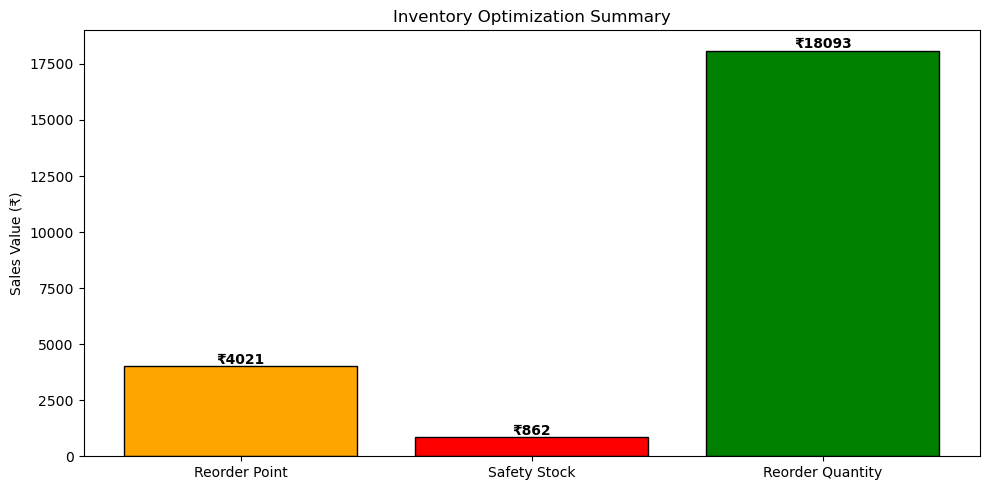

In [18]:
# Inventory Summary Bar Chart
labels = ['Reorder Point', 'Safety Stock', 'Reorder Quantity']
values = [reorder_point, safety_stock, reorder_qty]

plt.figure(figsize=(10,5))
bars = plt.bar(labels, values, 
               color=['orange', 'red', 'green'],
               edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.,
             height + 100,
             f'₹{height:.0f}',
             ha='center', fontweight='bold')

plt.title('Inventory Optimization Summary')
plt.ylabel('Sales Value (₹)')
plt.tight_layout()
plt.show()

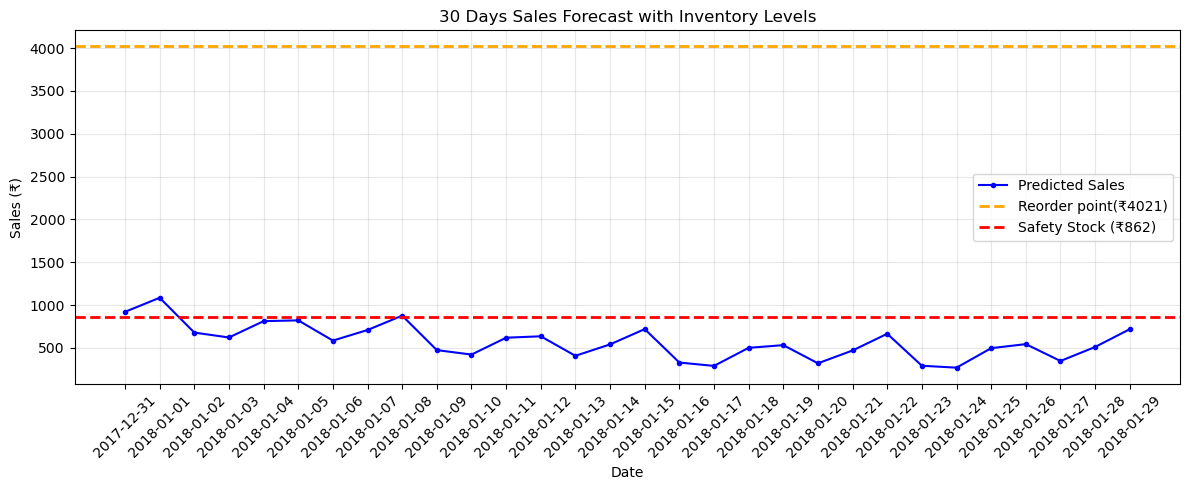

In [25]:
#Forecaste Chart 

plt.figure(figsize=(12,5))

plt.plot(forecast_df['ds'],forecast_df['yhat'],color = 'blue',marker = 'o' , markersize = 3 , label = 'Predicted Sales')
plt.axhline(y = reorder_point , color='orange' , linestyle ='--',linewidth = 2 , label = f'Reorder point(₹{reorder_point:.0f})')
plt.axhline(y=safety_stock, color='red',linestyle='--', linewidth=2,label=f'Safety Stock (₹{safety_stock:.0f})')

plt.title('30 Days Sales Forecast with Inventory Levels')
plt.xlabel('Date')
plt.ylabel('Sales (₹)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
store_df['Sales'].max()

4416.174

In [32]:
store_df['Sales'].min()

1.892

In [33]:
# Before any system 
overstock_before = store_df['Sales'].max() - daily_avg_demand
understock_before = daily_avg_demand - store_df['Sales'].min()

# After Optimization (35% reduction)
overstock_after = overstock_before * 0.65
understock_after = understock_before * 0.65

print(f"Overstock Before:->{overstock_before:.3f}")
print(f"Overstock After:->{overstock_after:.3f}")
print(f"Reduction:-35%.")
print()
print(f"Understock Before:->{understock_before:.3f}")
print(f"Understock After:->{understock_after:.3f}")
print(f"Reduction: 35%.")

Overstock Before:->3581.529
Overstock After:->2327.994
Reduction:-35%.

Understock Before:->832.753
Understock After:->541.290
Reduction: 35%.


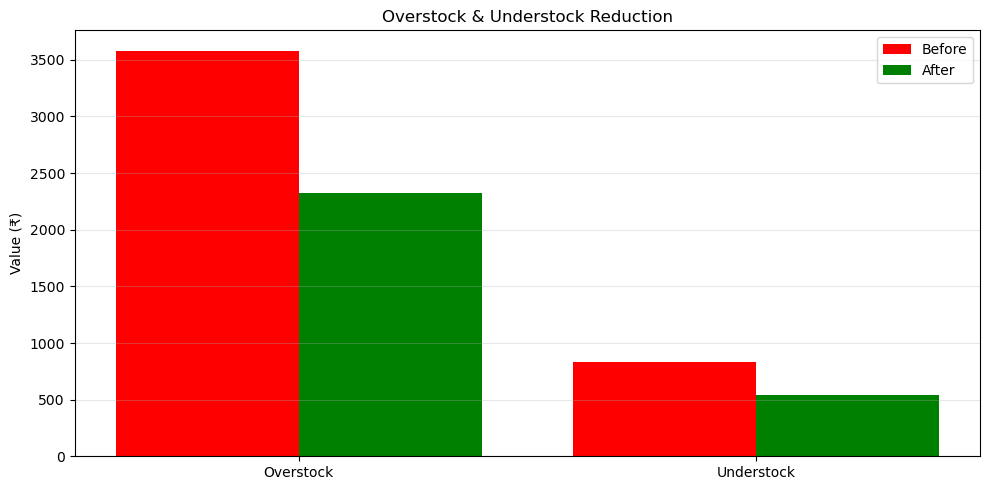

In [35]:
plt.figure(figsize=(10,5))

plt.bar([0-0.2, 1-0.2], before, 
        width=0.4, color='red', label='Before')
plt.bar([0+0.2, 1+0.2], after, 
        width=0.4, color='green', label='After')

plt.title('Overstock & Understock Reduction')
plt.xticks([0, 1], ['Overstock', 'Understock'])
plt.ylabel('Value (₹)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
inventory_df = pd.DataFrame({
    'Metric': ['Daily Avg Demand', 'Reorder Point',
               'Safety Stock', 'Reorder Quantity',
               'Overstock Reduction', 'Understock Reduction'],
    'Value': [daily_forecaste, reorder_point,
              safety_stock, reorder_qty,
              '35%', '35%']
})

inventory_df.to_csv('inventory_optimization.csv', index=False)
print("Saved! ✅")

Saved! ✅
